In [1]:
import os,sys
import ROOT
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

/opt/homebrew/Cellar/root/6.40.02_1/etc/root/cling/std_darwin.modulemap:14:18: error: header '__configuration/experimental.h' not found
  textual header "__configuration/experimental.h"
                 ^
input_line_1:1:10: note: submodule of top-level module 'std' implicitly imported here
#include <new>
         ^
Warning in cling::IncrementalParser::CheckABICompatibility():
  Failed to extract C++ standard library version.
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with _LIBCPP_ABI_VERSION '1'
  Extraction of runtime standard library version was: ''
IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function]!
You are probably missing the definition of cling::runtime::gCling
Maybe you need to load the corresponding shared library?
IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function

In [2]:
wdir = os.getcwd()
wdir

'/Users/aadesai1/Desktop/In_use/ACD_calibrations/reproducability_test'

In [3]:
generated_filename = f'{wdir}/new_files/elecgain/240212/r0729383941_gainPars.root'
website_filename = f'{wdir}/webversion/elecgain_240212_webversion/r0729383941_gainPars.root'
newer_generated_filename = f'{wdir}/newer_files/elecgain/r0729383941_gainPars.root'

In [4]:
def check_gain_root(filename):
    ROOT.gROOT.SetBatch(True)
    ROOT.gErrorIgnoreLevel = ROOT.kError
    data=[]
    f = ROOT.TFile.Open(filename)
    if not f or f.IsZombie():
        print("Failed to open: %s" % filename)
        return

    t = f.Get("ACD_Gain") 
    if not t:
        print("No ACD_Gain tree found")
        f.Close()
        return

    t.GetEntry(0)
    print("=== File Details ===")
    print("  startTime : %f" % t.startTime)
    print("  endTime   : %f" % t.endTime)
    print("  triggers  : %d" % t.triggers)

    print("\n  %6s %5s %10s %10s %8s" % ("id","pmt","peak","width","status"))
    print("  " + "-"*45)
    for i in range(216):
        print("  %6d %5d %10.3f %10.3f %8d" % (
            t.id[i], t.pmt[i], t.peak[i], t.width[i], t.status[i]))
    for i in range(216):
        data.append({
            'id'     : int(t.id[i]),
            'pmt'    : int(t.pmt[i]),
            'peak'   : float(t.peak[i]),
            'width'  : float(t.width[i]),
            'status' : int(t.status[i])
        })

    f.Close()
    return data


In [5]:
gendata = check_gain_root(generated_filename)

IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function]!
You are probably missing the definition of cling::runtime::gCling
Maybe you need to load the corresponding shared library?
IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function]!
You are probably missing the definition of cling::runtime::gCling
Maybe you need to load the corresponding shared library?
IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function]!
You are probably missing the definition of cling::runtime::gCling
Maybe you need to load the corresponding shared library?
IncrementalExecutor::executeFunction: symbol '_ZN5cling7runtime6gClingE' unresolved while linking [cling interface function]!
You are probably missing the definition of cling::runtime::gCling
Maybe you need to load the corresponding shared library?
Incr

=== File Details ===
  startTime : 729383944.677316
  endTime   : 729409455.086617
  triggers  : 2643280

      id   pmt       peak      width   status
  ---------------------------------------------
       0     0    626.429    170.536        0
       0     1    511.924    163.749        0
       1     0    523.936    168.149        0
       1     1    544.707    177.811        0
       2     0    435.437    141.954        0
       2     1    497.619    163.986        0
       3     0    472.634    167.285        0
       3     1    458.577    154.054        0
       4     0    631.400    173.193        0
       4     1    833.138    187.655        0
      10     0    367.676    148.932        0
      10     1    519.463    161.212        0
      11     0    462.198    168.499        0
      11     1    390.501    151.029        0
      12     0    560.897    168.889        0
      12     1    611.530    184.655        0
      13     0    453.276    154.823        0
      13     1    

In [6]:
website_data = check_gain_root(website_filename)

=== File Details ===
  startTime : 729383944.677316
  endTime   : 729409455.086617
  triggers  : 2643280

      id   pmt       peak      width   status
  ---------------------------------------------
       1 4294967295    626.429      0.000        0
       1 4294967295    523.936      0.000        0
       2     0    435.437    141.954        0
       3     0    472.634    167.284        0
       4     0    631.400    173.193        0
      10     0    367.676    148.930        0
      11     0    462.198    168.499        0
      12     0    560.898    168.889        0
      13     0    453.275    154.823        0
      14     0    537.789    161.010        0
      20     0    604.485    171.737        0
      21     0    543.331    160.297        0
      22     0    516.799    167.789        0
      23     0    428.737    135.642        0
      24     0    519.101    164.426        0
      30     0    602.144    177.595        0
      31     0    521.385    168.665        0
      32

In [7]:
newer_data = check_gain_root(newer_generated_filename)

=== File Details ===
  startTime : 729383944.677316
  endTime   : 729409455.086617
  triggers  : 2643280

      id   pmt       peak      width   status
  ---------------------------------------------
       0   710        nan      0.000        1
       1   711        nan      0.000        1
       2     0    435.437    141.954        0
       3     0    472.634    167.285        0
       4     0    631.400    173.193        0
      10     0    367.676    148.932        0
      11     0    462.198    168.499        0
      12     0    560.897    168.889        0
      13     0    453.276    154.823        0
      14     0    536.989    162.072        0
      20     0    604.485    171.737        0
      21     0    543.331    160.297        0
      22     0    516.799    167.789        0
      23     0    428.737    135.642        0
      24     0    519.102    164.424        0
      30     0    602.143    177.597        0
      31     0    521.385    168.665        0
      32     0    

In [8]:
def build_lookup(data):
    return {(d['id'], d['pmt']): d for d in data if d['status'] != -1}


In [20]:
lookup_new = build_lookup(newer_data)
lookup_old = build_lookup(website_data)
# ── Find Common Keys ──────────────────────────────────────────────────────────
common_keys = sorted(set(lookup_new.keys()) & set(lookup_old.keys()))
print("Common valid channels: %d" % len(common_keys))



Common valid channels: 192


In [21]:
# ── Find Common Keys ──────────────────────────────────────────────────────────
common_keys = sorted(set(lookup_new.keys()) & set(lookup_old.keys()))
print("Common valid channels: %d" % len(common_keys))

# ── Extract Matched Values ────────────────────────────────────────────────────
peaks_new   = [lookup_new[k]['peak']  for k in common_keys]
peaks_old   = [lookup_old[k]['peak']  for k in common_keys]
widths_new  = [lookup_new[k]['width'] for k in common_keys]
widths_old  = [lookup_old[k]['width'] for k in common_keys]

Common valid channels: 192


Saved: gain_comparison.png


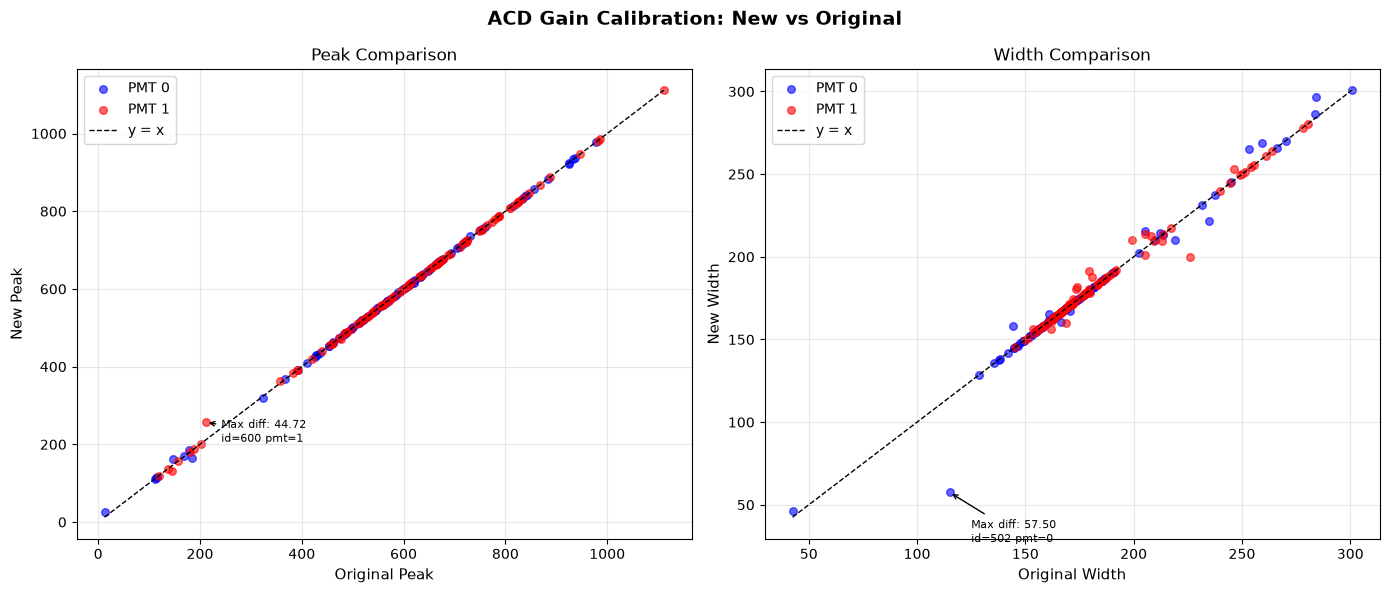

In [22]:
# Color by PMT
colors = ['blue' if k[1] == 0 else 'red' for k in common_keys]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ACD Gain Calibration: New vs Original", fontsize=14, fontweight='bold')

# --- Peak Scatter ---
ax = axes[0]
for pmt_val, color, label in [(0, 'blue', 'PMT 0'), (1, 'red', 'PMT 1')]:
    idx = [i for i, k in enumerate(common_keys) if k[1] == pmt_val]
    ax.scatter(
        [peaks_old[i] for i in idx],
        [peaks_new[i] for i in idx],
        c=color, label=label, alpha=0.6, s=30
    )

# Perfect agreement line
mn = min(peaks_old + peaks_new)
mx = max(peaks_old + peaks_new)
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
ax.set_xlabel("Original Peak", fontsize=11)
ax.set_ylabel("New Peak",      fontsize=11)
ax.set_title("Peak Comparison", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)


# Annotate max deviation
peak_diffs = np.abs(np.array(peaks_new) - np.array(peaks_old))
max_idx    = np.argmax(peak_diffs)
ax.annotate(
    "Max diff: %.2f\nid=%d pmt=%d" % (
        peak_diffs[max_idx],
        common_keys[max_idx][0],
        common_keys[max_idx][1]
    ),
    xy=(peaks_old[max_idx], peaks_new[max_idx]),
    xytext=(peaks_old[max_idx] + 30, peaks_new[max_idx] - 50),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=8
)

# --- Width Scatter ---
ax = axes[1]
for pmt_val, color, label in [(0, 'blue', 'PMT 0'), (1, 'red', 'PMT 1')]:
    idx = [i for i, k in enumerate(common_keys) if k[1] == pmt_val]
    ax.scatter(
        [widths_old[i] for i in idx],
        [widths_new[i] for i in idx],
        c=color, label=label, alpha=0.6, s=30
    )

mn = min(widths_old + widths_new)
mx = max(widths_old + widths_new)
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
ax.set_xlabel("Original Width", fontsize=11)
ax.set_ylabel("New Width",      fontsize=11)
ax.set_title("Width Comparison", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate max deviation
width_diffs = np.abs(np.array(widths_new) - np.array(widths_old))
max_idx     = np.argmax(width_diffs)
ax.annotate(
    "Max diff: %.2f\nid=%d pmt=%d" % (
        width_diffs[max_idx],
        common_keys[max_idx][0],
        common_keys[max_idx][1]
    ),
    xy=(widths_old[max_idx], widths_new[max_idx]),
    xytext=(widths_old[max_idx] + 10, widths_new[max_idx] - 30),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=8
)

plt.tight_layout()
plt.savefig("gain_comparison.png", dpi=150)
print("Saved: gain_comparison.png")
plt.show()



In [12]:
# ── Print Numerical Summary ───────────────────────────────────────────────────
print("\n=== Numerical Summary ===")
print("%-8s %-5s %10s %10s %10s %10s %10s %10s" % (
    "id","pmt","peak_old","peak_new","dpeak",
    "wid_old","wid_new","dwidth"))
print("-" * 80)
for i, k in enumerate(common_keys):
    dp = peaks_new[i]  - peaks_old[i]
    dw = widths_new[i] - widths_old[i]
    if abs(dp) > 5 or abs(dw) > 5:   # ← flag large differences
        flag = " ← !"
    else:
        flag = ""
    print("%-8d %-5d %10.3f %10.3f %10.3f %10.3f %10.3f %10.3f%s" % (
        k[0], k[1],
        peaks_old[i], peaks_new[i], dp,
        widths_old[i], widths_new[i], dw,
        flag
    ))




=== Numerical Summary ===
id       pmt     peak_old   peak_new      dpeak    wid_old    wid_new     dwidth
--------------------------------------------------------------------------------
0        1        511.925    511.924     -0.001    163.747    163.749      0.001
1        1        544.707    544.707     -0.001    177.811    177.811     -0.000
2        0        435.437    435.437     -0.000    141.954    141.954      0.000
2        1        497.619    497.619     -0.000    163.986    163.986     -0.000
3        0        472.634    472.634     -0.000    167.284    167.285      0.000
3        1        458.577    458.577      0.000    154.053    154.054      0.000
4        0        631.400    631.400      0.000    173.193    173.193      0.000
4        1        833.890    833.138     -0.753    180.944    187.655      6.711 ← !
10       0        367.676    367.676     -0.001    148.930    148.932      0.002
10       1        519.295    519.463      0.168    162.228    161.212     -1.0